# Extracción  y afincación de datos desde Kaggle

In [36]:
# Importacion de datos desde Kaggle con API

from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install kaggle --quiet
!mkdir -p ~/.kaggle
!echo $KAGGLE_API_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

!kaggle datasets download -d arshkon/linkedin-job-postings
!unzip -o linkedin-job-postings.zip

Dataset URL: https://www.kaggle.com/datasets/arshkon/linkedin-job-postings
License(s): CC-BY-SA-4.0
linkedin-job-postings.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  linkedin-job-postings.zip
  inflating: companies/companies.csv  
  inflating: companies/company_industries.csv  
  inflating: companies/company_specialities.csv  
  inflating: companies/employee_counts.csv  
  inflating: jobs/benefits.csv       
  inflating: jobs/job_industries.csv  
  inflating: jobs/job_skills.csv     
  inflating: jobs/salaries.csv       
  inflating: mappings/industries.csv  
  inflating: mappings/skills.csv     
  inflating: postings.csv            


In [37]:
# Carga y exploración inicial del dataset

import pandas as pd

df = pd.read_csv("postings.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(123849, 31)
['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [38]:
# Revisión de los niveles de experiencia disponibles (Entry, Mid-Senior, etc.)

df['formatted_experience_level'].value_counts(dropna=False)

,count
formatted_experience_level,
Mid-Senior level,41489
Entry level,36708
NaN,29409
Associate,9826
Director,3746
Internship,1449
Executive,1222


In [39]:
# Filtro de vacantes "Entry level" específicas de tech/sistemas

palabras_tech = (
    r'software engineer|software developer|web developer|application developer|'
    r'front[\s-]?end|back[\s-]?end|full[\s-]?stack|devops|'
    r'it support|it specialist|it technician|help desk|'
    r'systems administrator|systems analyst|network engineer|'
    r'data scientist|data analyst|data engineer|machine learning|'
    r'qa engineer|quality assurance engineer|software qa|'
    r'mobile developer|cloud engineer|database administrator|'
    r'programmer|computer science|java developer|python developer'
)

# Palabras que indican que NO es un rol de software/tech (para excluir aunque contengan "engineer")
palabras_excluir = (
    r'electrical|mechanical|manufacturing|quality program|rf |civil|'
    r'chemical|structural|process engineer|project engineer|product engineer'
)

entry_level = df[df['formatted_experience_level'] == 'Entry level']

es_tech = entry_level['title'].str.contains(palabras_tech, case=False, na=False, regex=True)
no_es_otro_campo = ~entry_level['title'].str.contains(palabras_excluir, case=False, na=False, regex=True)

tech_entry = entry_level[es_tech & no_es_otro_campo]

print(f"Vacantes 'entry level' en tech/sistemas: {tech_entry.shape[0]}")
tech_entry[['title', 'formatted_experience_level']].head(10)

Vacantes 'entry level' en tech/sistemas: 909


,title,formatted_experience_level
360,Cloud Platform/ Big Data Engineer,Entry level
372,Mobile Application Developer,Entry level
894,Database Administrator (BOCA RATON),Entry level
1020,IT QA Engineer II,Entry level
1236,Network Engineer,Entry level
1338,Data Scientist Job,Entry level
1845,Application Developer Supervisor - HYBRID,Entry level
1868,IT Support Specialist,Entry level
2179,Global IT Support Analyst (Pennington),Entry level
2212,IT Support Specialist,Entry level


In [40]:
# Recorte del dataset a 500 filas con criterio de calidad

tech_entry_clean = tech_entry[tech_entry['description'].str.len() > 100]
print(f"Después de filtrar por calidad: {tech_entry_clean.shape[0]}")

tech_entry_500 = tech_entry_clean.sample(n=500, random_state=42)
print(f"Dataset final: {tech_entry_500.shape}")

Después de filtrar por calidad: 909
Dataset final: (500, 31)


In [41]:
# Extracción de años de experiencia mencionados en la descripción

def extraer_anios_experiencia(texto):
    if pd.isna(texto):
        return None
    texto = texto.lower()

    # Ahora exigimos que la palabra "experience" esté pegada al número (no solo "years")
    patrones = [
        r'(\d+)\+?\s*(?:-\s*\d+\s*)?\s*years?\s*(?:of\s+)?(?:related\s+|relevant\s+|professional\s+|prior\s+|work(?:ing)?\s+)?experience',
        r'minimum\s*(?:of)?\s*(\d+)\s*years?\s*(?:of\s+)?experience',
        r'at\s*least\s*(\d+)\s*years?\s*(?:of\s+)?experience',
        r'(\d+)\s*to\s*\d+\s*years?\s*(?:of\s+)?experience',
    ]

    anios_encontrados = []
    for patron in patrones:
        matches = re.findall(patron, texto)
        anios_encontrados.extend([int(m) for m in matches])

    # Filtro de seguridad: ningún requisito individual real supera ~20 años
    # (valores más altos casi siempre son "historia de la empresa", no requisito del puesto)
    anios_encontrados = [a for a in anios_encontrados if 0 < a <= 20]

    if anios_encontrados:
        return min(anios_encontrados)
    return None

tech_entry_500 = tech_entry_500.copy()
tech_entry_500['anios_pedidos'] = tech_entry_500['description'].apply(extraer_anios_experiencia)
tech_entry_500['pide_experiencia'] = tech_entry_500['anios_pedidos'].notna() & (tech_entry_500['anios_pedidos'] > 0)

print(tech_entry_500['pide_experiencia'].value_counts())
print(f"\nPromedio de años pedidos (cuando aplica): {tech_entry_500['anios_pedidos'].mean():.1f}")
print(f"Mediana: {tech_entry_500['anios_pedidos'].median():.1f}")


pide_experiencia
False    337
True     163
Name: count, dtype: int64

Promedio de años pedidos (cuando aplica): 3.8
Mediana: 3.0


In [42]:
# Verificación manual: contexto real alrededor de cada detección

def mostrar_contexto(texto, patron_general=r'\d+\+?\s*(?:-\s*\d+\s*)?\s*years?'):
    texto_lower = texto.lower()
    match = re.search(patron_general, texto_lower)
    if match:
        inicio = max(0, match.start() - 100)
        fin = min(len(texto), match.end() + 100)
        return f"...{texto[inicio:fin]}..."
    return "(no se encontró contexto)"

ejemplos = tech_entry_500[tech_entry_500['pide_experiencia']].sample(5, random_state=1)

for idx, row in ejemplos.iterrows():
    print(f"TÍTULO: {row['title']}")
    print(f"AÑOS DETECTADOS: {row['anios_pedidos']}")
    print(f"CONTEXTO REAL: {mostrar_contexto(row['description'])}")
    print("-" * 80)

TÍTULO: Computer Vision/ Machine Learning Engineer
AÑOS DETECTADOS: 4.0
CONTEXTO REAL: ... technical development and fostering growth.


Qualifications:

MS or PhD in computer science or EE.4+ years of experience in machine learning and statistics, preferably in leading internet companies.Solid un...
--------------------------------------------------------------------------------
TÍTULO: IT Service Desk Specialist / Tier I IT Support
AÑOS DETECTADOS: 1.0
CONTEXTO REAL: ... recommendations for possible solutions


Qualifications


Bachelors Information Technology required2+ Years of experience in Windows, software, and endpoint support required1-2 Years of experience providing ...
--------------------------------------------------------------------------------
TÍTULO: Database Administrator Manager
AÑOS DETECTADOS: 10.0
CONTEXTO REAL: ...Basic Requirements:
• More than 10 years of experience in Database administration
• Solid hands on experience (5+ years) with Aurora Postgre...
-------

# Creación de gráfico

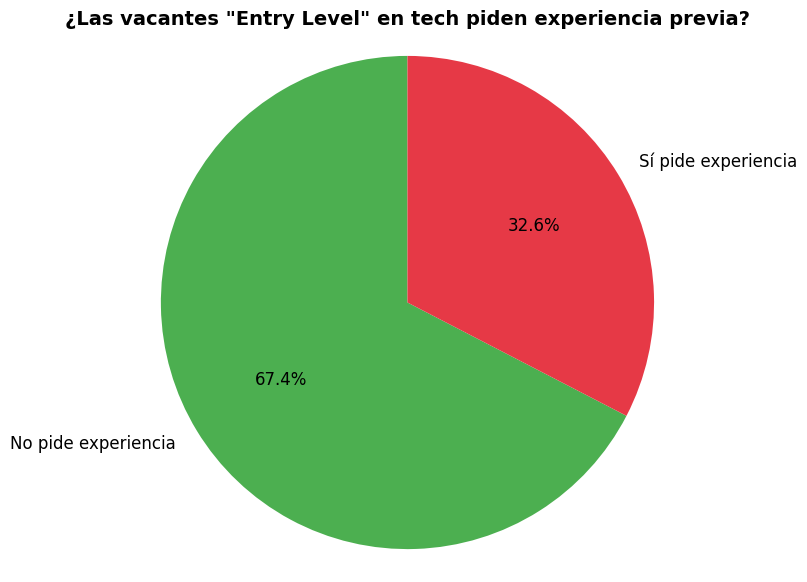

In [43]:
# Visualización: proporción de vacantes que piden experiencia vs. no

import matplotlib.pyplot as plt

conteo = tech_entry_500['pide_experiencia'].value_counts()
etiquetas = ['No pide experiencia', 'Sí pide experiencia']
colores = ['#4CAF50', '#E63946']

plt.figure(figsize=(7, 7))
plt.pie(conteo, labels=etiquetas, autopct='%1.1f%%', colors=colores, startangle=90,
        textprops={'fontsize': 12})
plt.title('¿Las vacantes "Entry Level" en tech piden experiencia previa?', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.savefig('grafico1_proporcion.png', dpi=150, bbox_inches='tight')
plt.show()

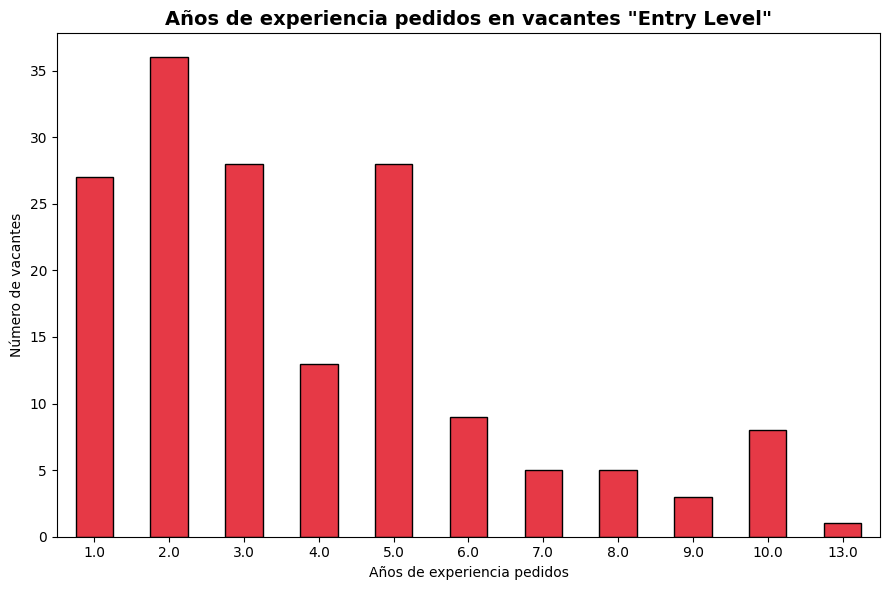

In [44]:
# Visualización: distribución de años de experiencia pedidos

plt.figure(figsize=(9, 6))
tech_entry_500[tech_entry_500['pide_experiencia']]['anios_pedidos'].value_counts().sort_index().plot(
    kind='bar', color='#E63946', edgecolor='black'
)
plt.title('Años de experiencia pedidos en vacantes "Entry Level"', fontsize=14, fontweight='bold')
plt.xlabel('Años de experiencia pedidos')
plt.ylabel('Número de vacantes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('grafico2_distribucion_anios.png', dpi=150, bbox_inches='tight')
plt.show()

                 mean  count
categoria_rol               
QA               60.0     10
Systems/Network  41.5     65
Developer        34.0     94
Otro             32.4    136
Data             30.6    121
IT Support       23.0     74


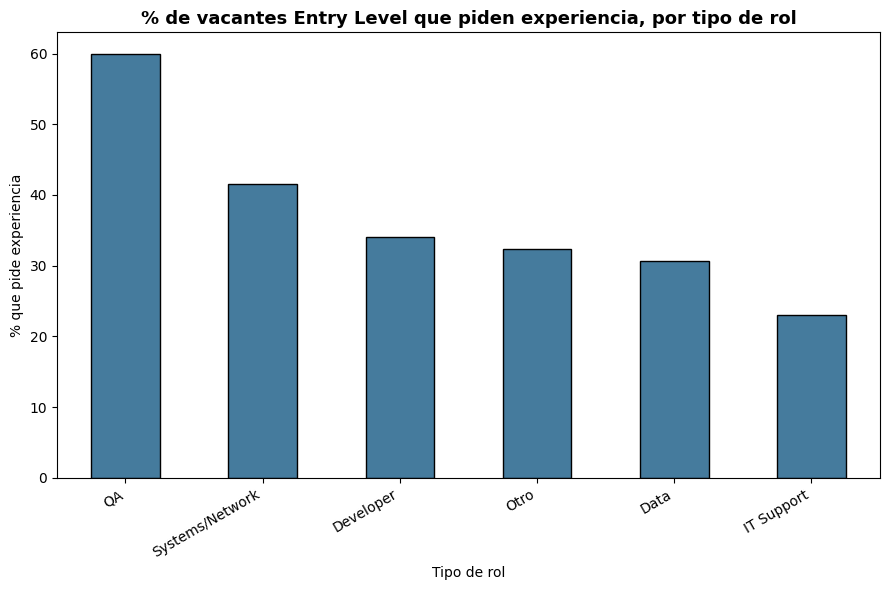

In [48]:
# Clasificamos cada vacante en una categoría de rol más general

def categorizar_rol(titulo):
    titulo = titulo.lower()
    if 'developer' in titulo or 'programmer' in titulo:
        return 'Developer'
    elif 'data scientist' in titulo or 'data analyst' in titulo or 'data engineer' in titulo:
        return 'Data'
    elif 'it support' in titulo or 'help desk' in titulo or 'it specialist' in titulo or 'it technician' in titulo:
        return 'IT Support'
    elif 'systems' in titulo or 'network' in titulo or 'administrator' in titulo:
        return 'Systems/Network'
    elif 'qa' in titulo or 'quality assurance' in titulo:
        return 'QA'
    else:
        return 'Otro'

tech_entry_500['categoria_rol'] = tech_entry_500['title'].apply(categorizar_rol)

resumen = tech_entry_500.groupby('categoria_rol')['pide_experiencia'].agg(['mean', 'count'])
resumen['mean'] = (resumen['mean'] * 100).round(1)
resumen = resumen.sort_values('mean', ascending=False)
print(resumen)

plt.figure(figsize=(9, 6))
resumen['mean'].plot(kind='bar', color='#457B9D', edgecolor='black')
titulo_grafico = '% de vacantes Entry Level que piden experiencia, por tipo de rol'
plt.title(titulo_grafico, fontsize=13, fontweight='bold')
plt.ylabel('% que pide experiencia')
plt.xlabel('Tipo de rol')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('grafico3_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

# Exportar DATASET

In [49]:
# Seleccionamos solo las columnas relevantes para el análisis

columnas_finales = ['job_id', 'title', 'formatted_experience_level', 'categoria_rol',
                     'anios_pedidos', 'pide_experiencia', 'description']

dataset_final = tech_entry_500[columnas_finales]
dataset_final.to_csv('entry_level_tech_jobs_clean.csv', index=False)

print(f"Dataset exportado: {dataset_final.shape}")
dataset_final.head()

Dataset exportado: (500, 7)


,job_id,title,formatted_experience_level,categoria_rol,anios_pedidos,pide_experiencia,description
117343,3905885146,Data Analyst: 24-00481,Entry level,Data,2.0,True,"Top 3 Skills\n\nMS Excel, MS PowerPoint, Data ..."
67165,3902752818,IT Support Analyst,Entry level,IT Support,NaN,False,About The Role\n\nThe IT Support Analyst works...
47115,3900982560,Associate Network Engineer NI Academy,Entry level,Systems/Network,NaN,False,About Lumen\n\nLumen connects the world. We ar...
100149,3905207302,Cloud Software Engineer,Entry level,Otro,5.0,True,Job ID: 18437\n\nThe Space Dynamics Laboratory...
106908,3905330162,Oracle IT Programmer,Entry level,Developer,5.0,True,Oracle Software Engineer \n\nWhat you’ll do:\n...
